In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Understand the Dataset

### Check Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Summary Statistics

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Check columns

In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

### Dataset shape

In [7]:
df.shape

(768, 9)

### DATA CLEANING

In [8]:
# Check Zero Values

In [9]:
(df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [10]:
# Replace Zero Values

In [4]:

import numpy as np

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

In [12]:
 ## Fill Missing Values

In [13]:
df.fillna(df.median(), inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


### Check Missing Values

In [15]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Exploratory Data Analysis (EDA)

In [16]:
# Question 1
# How many patients have diabetes?

In [17]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [18]:
## Percentage:

In [19]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

### Visualization

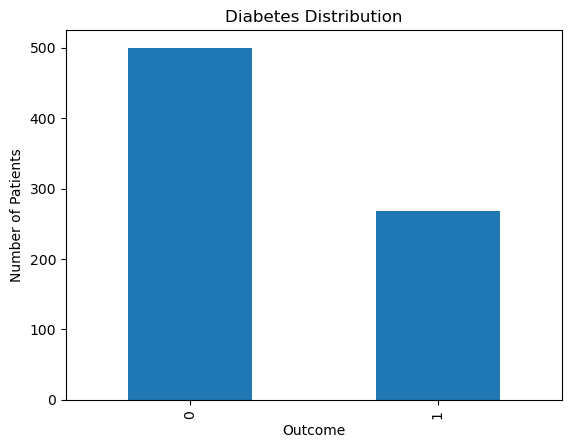

In [20]:
df["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

In [21]:
# Insight
# Determine the percentage of diabetic and non-diabetic patients.

In [22]:
## Question 2
## Average Glucose by Outcome

In [23]:
df.groupby("Outcome")["Glucose"].mean()

Outcome
0    110.682000
1    142.130597
Name: Glucose, dtype: float64

### Visualization

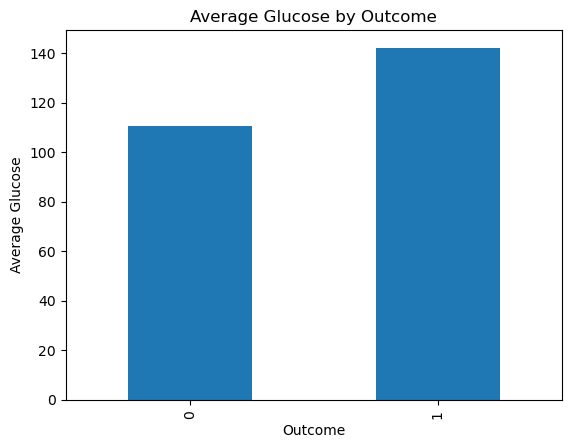

In [24]:
df.groupby("Outcome")["Glucose"].mean().plot(kind="bar")

plt.title("Average Glucose by Outcome")
plt.ylabel("Average Glucose")

plt.show()

In [25]:
## Insights
## Compare glucose levels between diabetic and non-diabetic patients.

In [26]:
## Question 3
## Average BMI by Outcome

In [27]:
df.groupby("Outcome")["BMI"].mean()

Outcome
0    30.885600
1    35.383582
Name: BMI, dtype: float64

### Visualization

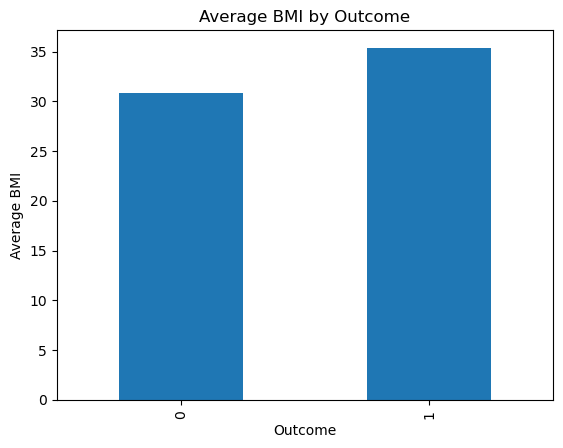

In [28]:
df.groupby("Outcome")["BMI"].mean().plot(kind="bar")

plt.title("Average BMI by Outcome")
plt.ylabel("Average BMI")

plt.show()

In [29]:
## Insight
## Assess whether obesity is associated with diabetes.

In [30]:
## Question 4
## Average Age by Outcome

In [31]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

In [32]:
## Visualization

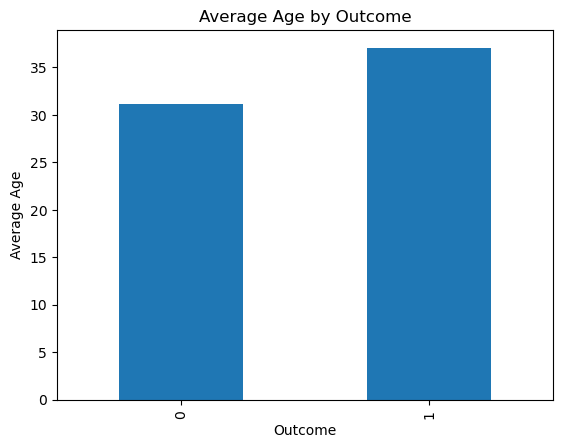

In [33]:
df.groupby("Outcome")["Age"].mean().plot(kind="bar")

plt.title("Average Age by Outcome")
plt.ylabel("Average Age")

plt.show()

In [34]:
# Insight
# Determine whether diabetic patients tend to be older.

In [35]:
# Question 5
# Family History Analysis

In [36]:
df.groupby("Outcome")["DiabetesPedigreeFunction"].mean()

Outcome
0    0.429734
1    0.550500
Name: DiabetesPedigreeFunction, dtype: float64

In [37]:
# Visualization

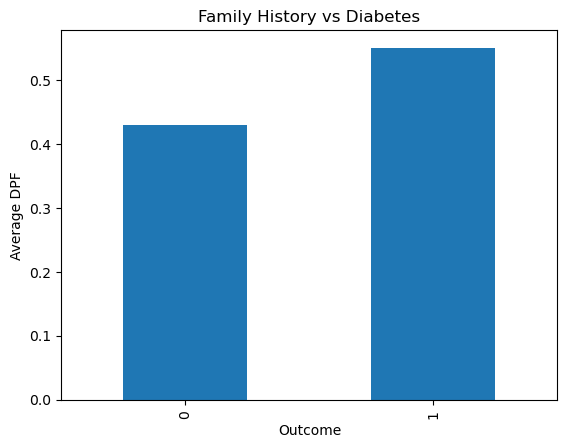

In [38]:
df.groupby("Outcome")["DiabetesPedigreeFunction"].mean().plot(kind="bar")

plt.title("Family History vs Diabetes")
plt.ylabel("Average DPF")

plt.show()

In [39]:
# Insight
# Assess whether family history contributes to diabetes risk.

In [40]:
# Step 6: Create Age Groups

In [41]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 29, 49, 100],
    labels=["Young", "Middle Age", "Senior"]
)

In [42]:
# Check:

In [43]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Senior
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Middle Age
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Middle Age
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Young
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Middle Age


In [44]:
# Diabetes by Age Group

In [45]:
pd.crosstab(df["Age_Group"], df["Outcome"])

Outcome,0,1
Age_Group,,
Young,312,84
Middle Age,142,141
Senior,46,43


In [46]:
# Visualization

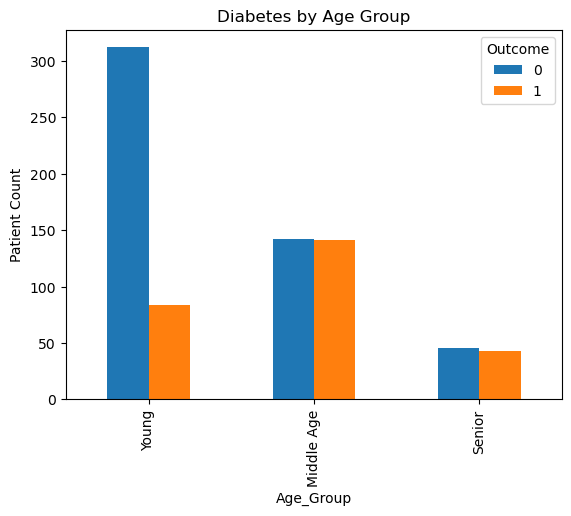

In [47]:
pd.crosstab(df["Age_Group"], df["Outcome"]).plot(kind="bar")

plt.title("Diabetes by Age Group")
plt.ylabel("Patient Count")

plt.show()

In [48]:
# Insight
# Determine whether diabetes prevalence increases with age.

In [49]:
# Step 7: High-Risk Patients

In [50]:
# High Glucose Patients

In [51]:
high_glucose = df[df["Glucose"] > 140]

high_glucose.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Senior
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Middle Age
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,Senior
11,10,168.0,74.0,29.0,125.0,38.0,0.537,34,1,Middle Age
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1,Senior


In [52]:
# Count:

In [53]:
len(high_glucose)

192

In [54]:
# High BMI Patients

In [55]:
high_bmi = df[df["BMI"] > 30]

high_bmi.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Senior
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Middle Age
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1,Young
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0,Young
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,Senior


In [56]:
# Count

In [57]:
len(high_bmi)

476

In [58]:
# High Glucose and High BMI

In [59]:
high_risk = df[
    (df["Glucose"] > 140) &
    (df["BMI"] > 30)
]

high_risk.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Senior
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,Senior
11,10,168.0,74.0,29.0,125.0,38.0,0.537,34,1,Middle Age
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1,Senior
22,7,196.0,90.0,29.0,125.0,39.8,0.451,41,1,Middle Age


In [60]:
# Count:

In [61]:
len(high_risk)

148

In [62]:
# Scatter Plot Analysis

In [63]:
# BMI vs Glucose

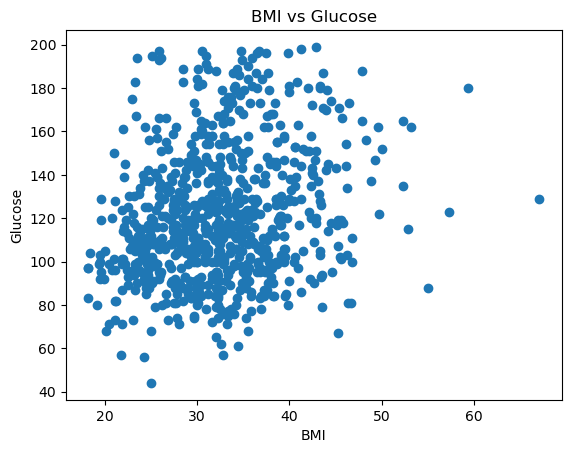

In [64]:
plt.scatter(df["BMI"], df["Glucose"])

plt.title("BMI vs Glucose")
plt.xlabel("BMI")
plt.ylabel("Glucose")

plt.show()

In [65]:
# Insight
# Look for patterns between BMI and glucose levels.

In [66]:
# Correlation Analysis
# One of the most important EDA steps.

In [67]:
df.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


In [68]:
# Correlation with Diabetes

In [69]:
df.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

In [70]:
# Business Insight
# Identify the variables most strongly associated with diabetes.

In [71]:
# Save Cleaned Dataset

In [73]:
df.to_csv(
    "diabetes_final.csv",
    index=False
)